In [139]:
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from sklearn.cluster import KMeans
from skimage.measure import label, regionprops

In [140]:
BASE = "/kaggle/input/raabindata-nucleus-cytoplasm-ground-truths/GrTh"
ORIG = os.path.join(BASE, "Original")
GT   = os.path.join(BASE, "Ground Truth")
cell_types = ["Eosinophil","Lymphocyte","Monocyte","Neutrophil","Basophil"]

In [141]:
def extract_wbc(img):

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    b_channel = lab[:,:,2]

    _, th = cv2.threshold(
        b_channel, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5,5), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)

    labels = label(th)
    regions = regionprops(labels)

    if len(regions) == 0:
        return None

    largest = max(regions, key=lambda r: r.area)

    return (labels == largest.label).astype(np.uint8)

In [142]:
def fcm_manual(pixels, k=2, m=2, max_iter=100, epsilon=1e-5):

    N = pixels.shape[0]

    U = np.random.dirichlet(np.ones(k), size=N)

    for _ in range(max_iter):

        U_old = U.copy()

        um = U ** m
        centers = (um.T @ pixels) / (np.sum(um, axis=0)[:,None] + 1e-8)

        dist = np.linalg.norm(
            pixels[:,None,:] - centers[None,:,:],
            axis=2
        ) + 1e-8

        power = 2/(m-1)
        inv_dist = dist ** (-power)
        U = inv_dist / np.sum(inv_dist, axis=1, keepdims=True)

        if np.linalg.norm(U - U_old) < epsilon:
            break

    labels = np.argmax(U, axis=1)
    return labels, centers

In [143]:
def boundary(mask):
    kernel = np.ones((3,3),np.uint8)
    return cv2.morphologyEx(mask.astype(np.uint8),
                            cv2.MORPH_GRADIENT,
                            kernel)

def boundary_f1(pred, gt):

    pb = boundary(pred)
    gb = boundary(gt)

    inter = np.logical_and(pb, gb).sum()
    precision = inter / (pb.sum()+1e-8)
    recall    = inter / (gb.sum()+1e-8)

    return 2*precision*recall/(precision+recall+1e-8)

In [144]:
results = []

for cell in cell_types:

    img_paths  = glob(os.path.join(ORIG, cell, "**", "*.*"), recursive=True)
    mask_paths = glob(os.path.join(GT, cell, "**", "*.*"), recursive=True)

    img_paths  = sorted([p for p in img_paths if p.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
    mask_paths = sorted([p for p in mask_paths if p.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])

    km_scores  = []
    fcm_scores = []

    print(f"Processing {cell} → {len(img_paths)} images")

Processing Eosinophil → 201 images
Processing Lymphocyte → 242 images
Processing Monocyte → 242 images
Processing Neutrophil → 242 images
Processing Basophil → 218 images


In [145]:
    for img_path, mask_path in zip(img_paths, mask_paths):

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        gt  = cv2.imread(mask_path, 0)

        img = cv2.resize(img, (224,224))
        gt  = cv2.resize(gt, (224,224))

        gt_nucleus = (gt > 128).astype(np.uint8)

        wbc = extract_wbc(img)
        if wbc is None:
            continue

        # -------------------------
        # LAB Features (3D)
        # -------------------------
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        pixels = lab[wbc==1].reshape(-1,3)

In [146]:
        km = KMeans(n_clusters=2, random_state=42).fit(pixels)
        centers = km.cluster_centers_

        nucleus_cluster = np.argmin(centers[:,0])  # darker L channel

        labels_full = np.zeros(wbc.shape)
        labels_full[wbc==1] = km.labels_

        km_nucleus = (labels_full==nucleus_cluster).astype(np.uint8)

In [147]:
        f_labels, f_centers = fcm_manual(pixels, k=2)

        nucleus_cluster = np.argmin(f_centers[:,0])

        labels_full = np.zeros(wbc.shape)
        labels_full[wbc==1] = f_labels

        fcm_nucleus = (labels_full==nucleus_cluster).astype(np.uint8)


In [148]:
        km_scores.append(boundary_f1(km_nucleus, gt_nucleus))
        fcm_scores.append(boundary_f1(fcm_nucleus, gt_nucleus))

        results.append([
        cell,
        np.mean(km_scores),
        np.mean(fcm_scores)
        ])

In [149]:
df = pd.DataFrame(results,
                  columns=["Cell Type",
                           "KM Boundary F1",
                           "FCM Boundary F1"])

print("\nPer-Class Boundary F1:")
print(df)

print("\nOverall Average:")
print("KMeans :", round(df["KM Boundary F1"].mean(),3))
print("FCM    :", round(df["FCM Boundary F1"].mean(),3))


Per-Class Boundary F1:
  Cell Type  KM Boundary F1  FCM Boundary F1
0  Basophil         0.22971         0.066254

Overall Average:
KMeans : 0.23
FCM    : 0.066


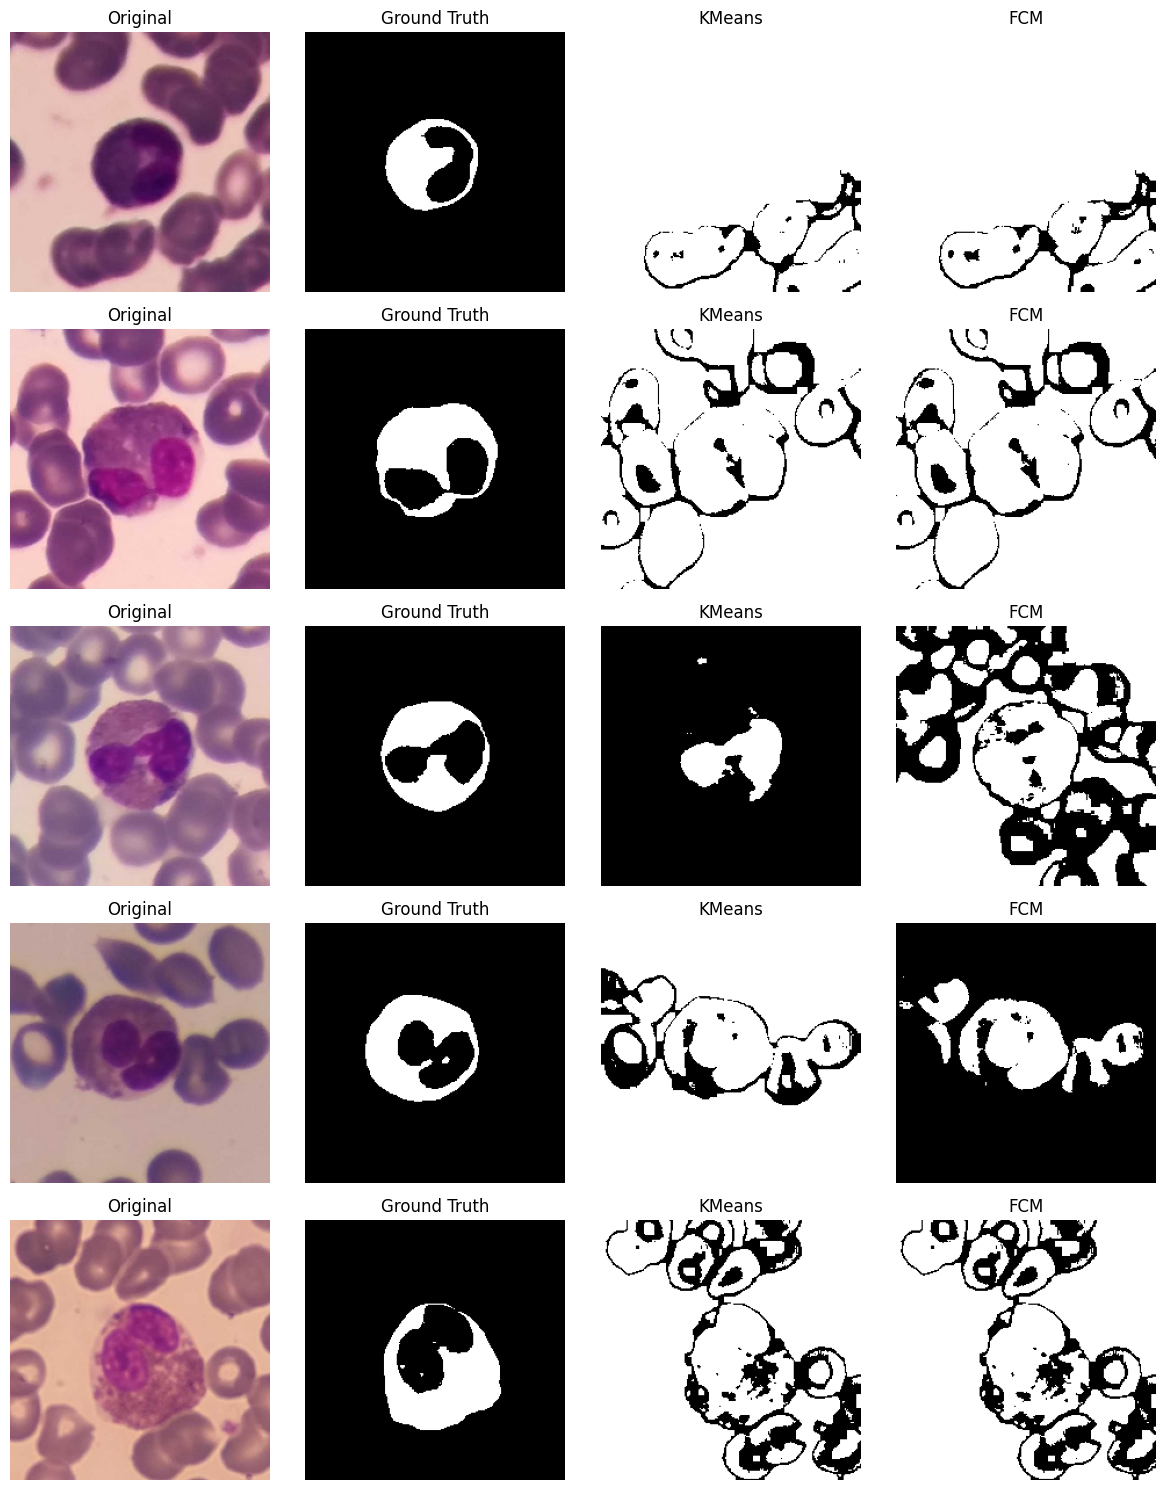

In [150]:

import matplotlib.pyplot as plt

sample_count = 5
shown = 0

plt.figure(figsize=(12, sample_count * 3))

for cell in cell_types:

    img_paths  = glob(os.path.join(ORIG, cell, "**", "*.*"), recursive=True)
    mask_paths = glob(os.path.join(GT, cell, "**", "*.*"), recursive=True)

    img_paths  = sorted([p for p in img_paths if p.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
    mask_paths = sorted([p for p in mask_paths if p.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])

    for img_path, mask_path in zip(img_paths, mask_paths):

        if shown >= sample_count:
            break

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        gt  = cv2.imread(mask_path, 0)

        img = cv2.resize(img, (224,224))
        gt  = cv2.resize(gt, (224,224))
        gt_nucleus = (gt > 128).astype(np.uint8)

        wbc = extract_wbc(img)
        if wbc is None:
            continue

        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        pixels = lab[wbc==1].reshape(-1,3)

        # KMeans
        km = KMeans(n_clusters=2, random_state=42).fit(pixels)
        centers = km.cluster_centers_
        nucleus_cluster = np.argmin(centers[:,0])

        labels_full = np.zeros(wbc.shape)
        labels_full[wbc==1] = km.labels_
        km_nucleus = (labels_full==nucleus_cluster).astype(np.uint8)

        # FCM
        f_labels, f_centers = fcm_manual(pixels, k=2)
        labels_full = np.zeros(wbc.shape)
        labels_full[wbc==1] = f_labels
        nucleus_cluster = np.argmin(f_centers[:,0])
        fcm_nucleus = (labels_full==nucleus_cluster).astype(np.uint8)

        # Plot
        plt.subplot(sample_count, 4, shown*4 + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(sample_count, 4, shown*4 + 2)
        plt.imshow(gt_nucleus, cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(sample_count, 4, shown*4 + 3)
        plt.imshow(km_nucleus, cmap='gray')
        plt.title("KMeans")
        plt.axis('off')

        plt.subplot(sample_count, 4, shown*4 + 4)
        plt.imshow(fcm_nucleus, cmap='gray')
        plt.title("FCM")
        plt.axis('off')

        shown += 1

    if shown >= sample_count:
        break

plt.tight_layout()
plt.show()